# Week 9 Challenge

# Task 2 - Time Series Forecasting

Author: Lalise Fufi

Date: July 2026

Objective:
Develop, train and compare ARIMA and LSTM models for forecasting Tesla stock prices.

1. Import Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

plt.style.use("ggplot")

2. Load Tesla Data

In [2]:
tsla = pd.read_csv("../data/raw/TSLA.csv")

print(tsla.head())
print(tsla.columns)

        Price               Close                High                 Low  \
0      Ticker                TSLA                TSLA                TSLA   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02  14.620667457580566  14.883333206176758   14.21733283996582   
3  2015-01-05  14.005999565124512  14.433333396911621  13.810667037963867   
4  2015-01-06  14.085332870483398  14.279999732971191   13.61400032043457   

                 Open    Volume  
0                TSLA      TSLA  
1                 NaN       NaN  
2  14.857999801635742  71466000  
3  14.303333282470703  80527500  
4  14.003999710083008  93928500  
Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [3]:
# ==========================================================
# Load Tesla Data
# ==========================================================

tsla = pd.read_csv(
    "../data/raw/TSLA.csv",
    skiprows=[1],      
    index_col=0,       
    parse_dates=True
)

tsla.index.name = "Date"

tsla.head()

,Close,High,Low,Open,Volume
Date,,,,,
Date,NaN,NaN,NaN,NaN,NaN
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000.0
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500.0
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500.0
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000.0


3. Select Closing Price

In [4]:
close = tsla["Close"]

close.head()

Date
Date                NaN
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
Name: Close, dtype: float64

4. Plot Closing Price

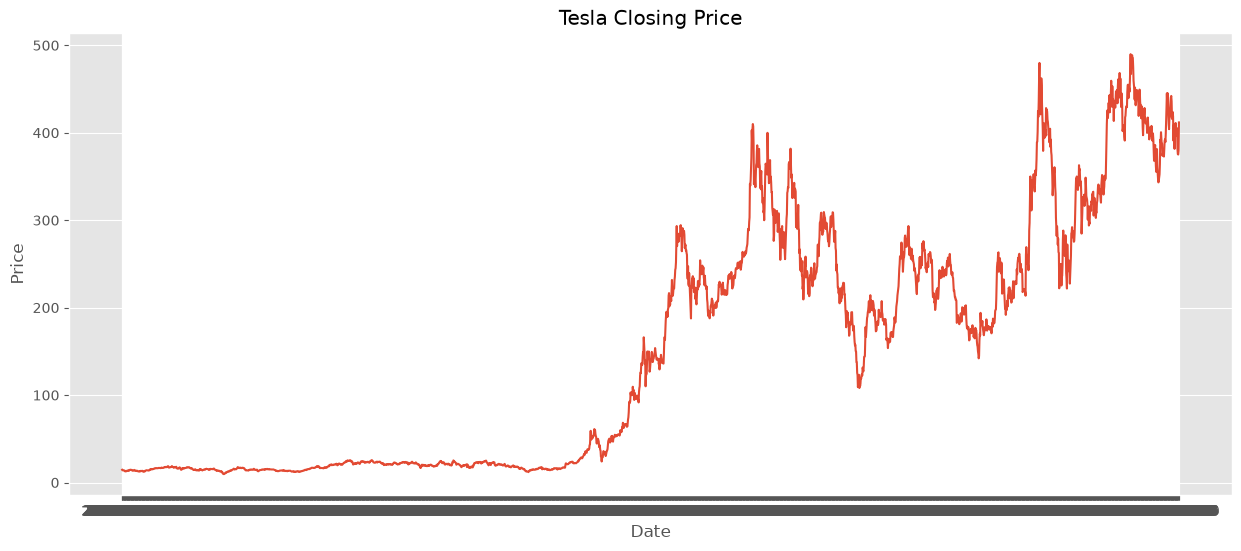

In [5]:
plt.figure(figsize=(15,6))

plt.plot(close)

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

## Interpretation of Tesla Closing Price

The Tesla closing price chart illustrates the historical movement of Tesla's stock price from 2015 to 2026.

- From **2015 to 2019**, Tesla's stock price remained relatively stable with only gradual growth and limited price fluctuations.
- Beginning in **2020**, the stock experienced a sharp upward trend, reflecting increased investor confidence and rapid company growth.
- During **2021 and 2022**, Tesla exhibited significant price volatility, with several sharp increases and declines. This period indicates greater market uncertainty and higher investment risk.
- Although the price declined during parts of **2022–2023**, Tesla recovered strongly afterward, reaching new highs in **2025–2026**.
- Overall, Tesla demonstrates a strong long-term upward trend despite experiencing substantial short-term fluctuations.

### Conclusion

The chart suggests that **Tesla is a high-growth but highly volatile asset**. Investors may benefit from its long-term appreciation, but they should also be prepared for considerable short-term price swings. These characteristics make Tesla a higher-risk investment compared with diversified ETFs such as BND and SPY.

4. Train Test Split

Train → 2015–2024

Test → 2025–2026

In [6]:
print(close.index)
print(type(close.index))
print(close.index.is_monotonic_increasing)

Index(['Date', '2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
       '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14',
       ...
       '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22',
       '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29'],
      dtype='str', name='Date', length=2889)
<class 'pandas.Index'>
False


In [7]:
close = close.sort_index()

In [8]:
train = close[:'2024-12-31']

test = close['2025-01-01':]

print(train.shape)

print(test.shape)

(2516,)
(373,)


In [9]:
print(close.index.min())
print(close.index.max())

2015-01-02
Date


5. Plot Train/Test

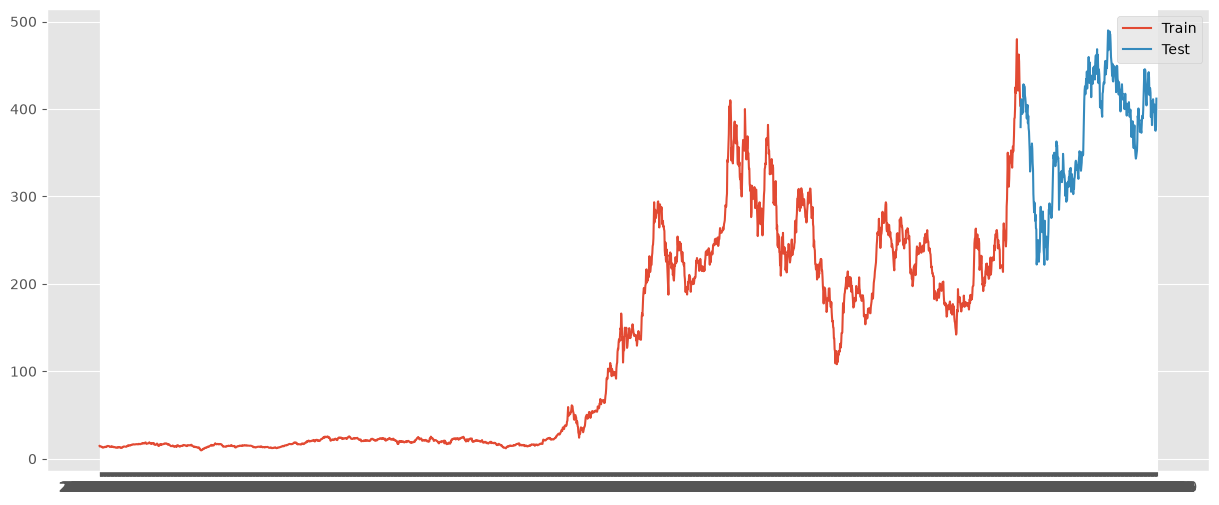

In [10]:
plt.figure(figsize=(15,6))

plt.plot(train,label="Train")

plt.plot(test,label="Test")

plt.legend()

plt.show()

## Interpretation of Training and Testing Data Split

The plot illustrates the division of Tesla's closing price data into **training** and **testing** datasets for time series forecasting.

- The **training dataset** (red line) contains the historical observations used to train the forecasting model. It captures Tesla's long-term price behavior, including periods of rapid growth and significant volatility.
- The **testing dataset** (blue line) represents the unseen data reserved for evaluating the model's forecasting performance. This ensures that the model is tested on data it has not previously encountered.
- The transition between the training and testing sets is continuous, indicating that the chronological order of the time series has been preserved. This is essential for time series forecasting because future observations should never be used to predict past values.
- The testing period continues to exhibit substantial price fluctuations, making it a realistic benchmark for assessing the model's ability to forecast highly volatile stock prices.

### Conclusion

The train-test split follows the correct approach for time series analysis by maintaining the temporal sequence of the data. The majority of historical observations are used for model training, while the most recent observations are reserved for testing, allowing an unbiased evaluation of forecasting accuracy.

6. ACF Plot

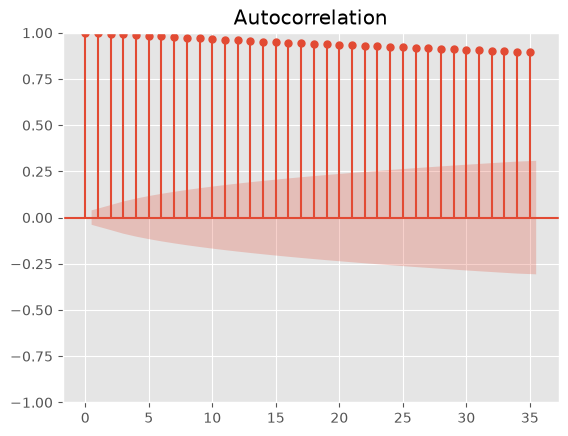

In [11]:
plot_acf(train)

plt.show()

7. PACF Plot

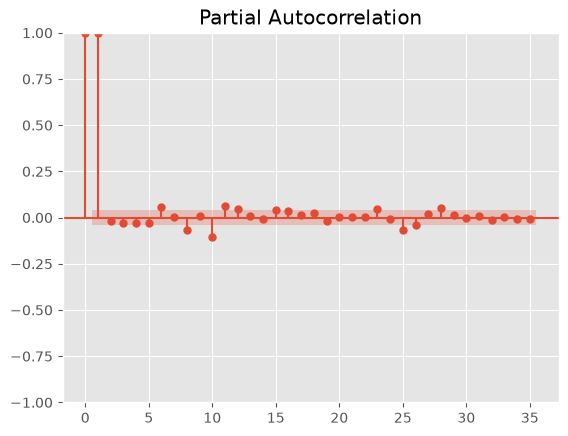

In [12]:
plot_pacf(train)

plt.show()

8. Auto ARIMA

In [13]:
auto_model = auto_arima(

    train,

    seasonal=False,

    trace=True,

    suppress_warnings=True,

    stepwise=True

)

auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.86 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.591 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 21 Jul 2026   AIC                          16368.109
Time:                        11:23:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):             536.79   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

9. Best Parameters

In [14]:
print(auto_model.order)

(0, 1, 0)


10. Build ARIMA

In [15]:
arima = ARIMA(

    train,

    order=auto_model.order

)

arima_model = arima.fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 21 Jul 2026   AIC                          16368.109
Time:                        11:23:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

c:\Users\Administrator\projects\portfolio-optimization-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Administrator\projects\portfolio-optimization-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Administrator\projects\portfolio-optimization-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


11. Forecast Test Period

In [16]:
forecast = arima_model.forecast(

    steps=len(test)

)

c:\Users\Administrator\projects\portfolio-optimization-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


12. Plot Forecast

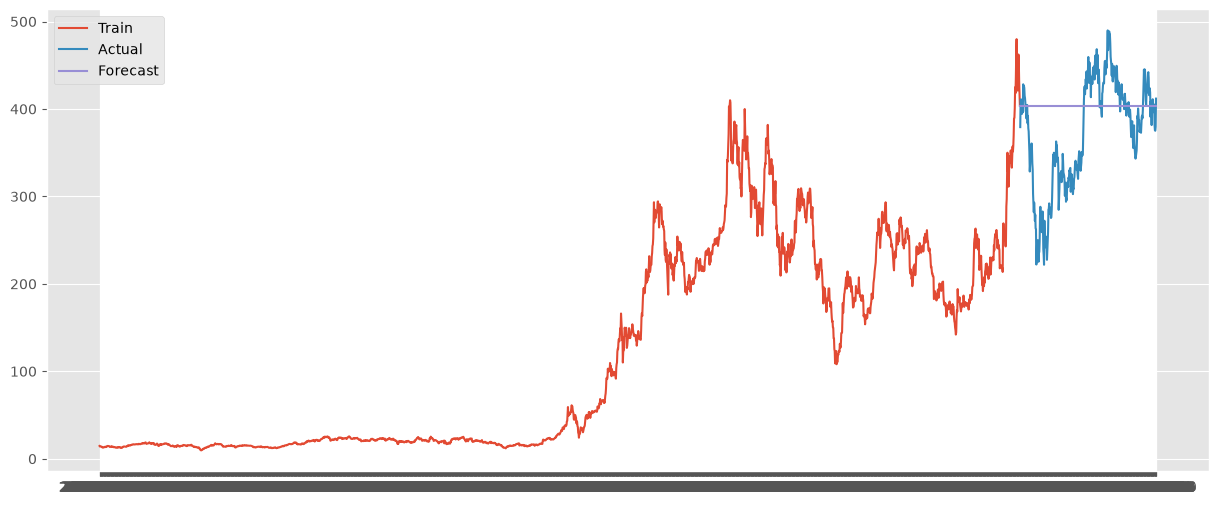

In [17]:
plt.figure(figsize=(15,6))

plt.plot(train,label="Train")

plt.plot(test,label="Actual")

plt.plot(test.index,forecast,label="Forecast")

plt.legend()

plt.show()

13. ARIMA Metrics

In [18]:
print("NaN in test:")
print(test.isna().sum())

print("\nNaN in forecast:")
print(np.isnan(forecast).sum())

NaN in test:
1

NaN in forecast:
0


In [19]:
print(test[test.isna()])

Date
Date   NaN
Name: Close, dtype: float64


In [20]:
test = test.dropna()

In [21]:
print(len(test))
print(len(forecast))

372
373


In [22]:
forecast = forecast[:len(test)]

In [23]:
mae = mean_absolute_error(test,forecast)

rmse = np.sqrt(mean_squared_error(test,forecast))

mape = mean_absolute_percentage_error(test,forecast)

print(mae)

print(rmse)

print(mape)

54.44118233137233
70.53934610418263
0.17240653410477236


13. Scale Data for LSTM

In [24]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(

    close.values.reshape(-1,1)

)

14. Create Sequences

In [25]:
window = 60

X=[]

y=[]

for i in range(window,len(scaled)):

    X.append(scaled[i-window:i])

    y.append(scaled[i])

X=np.array(X)

y=np.array(y)

15. Train/Test Split

In [26]:
split = len(train)

X_train = X[:split-window]

X_test = X[split-window:]

y_train = y[:split-window]

y_test = y[split-window:]

16. Build LSTM

In [27]:
model = Sequential()

model.add(

    LSTM(

        64,

        return_sequences=True,

        input_shape=(60,1)

    )

)

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(1))

17. Compile

In [28]:
model.compile(

    optimizer="adam",

    loss="mse"

)

18. Train

In [29]:
history = model.fit(

    X_train,

    y_train,

    epochs=20,

    batch_size=32,

    validation_split=0.1,

    verbose=1

)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - loss: 0.0077 - val_loss: 0.0025
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0016 - val_loss: 0.0026
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0012 - val_loss: 0.0026
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 9.1476e-04 - val_loss: 0.0017
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 9.9010e-04 - val_loss: 0.0015
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 9.6548e-04 - val_loss: 0.0025
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/s

19. Predict

In [30]:
pred = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


20. Inverse Scaling

In [31]:
pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(y_test)

21. Plot

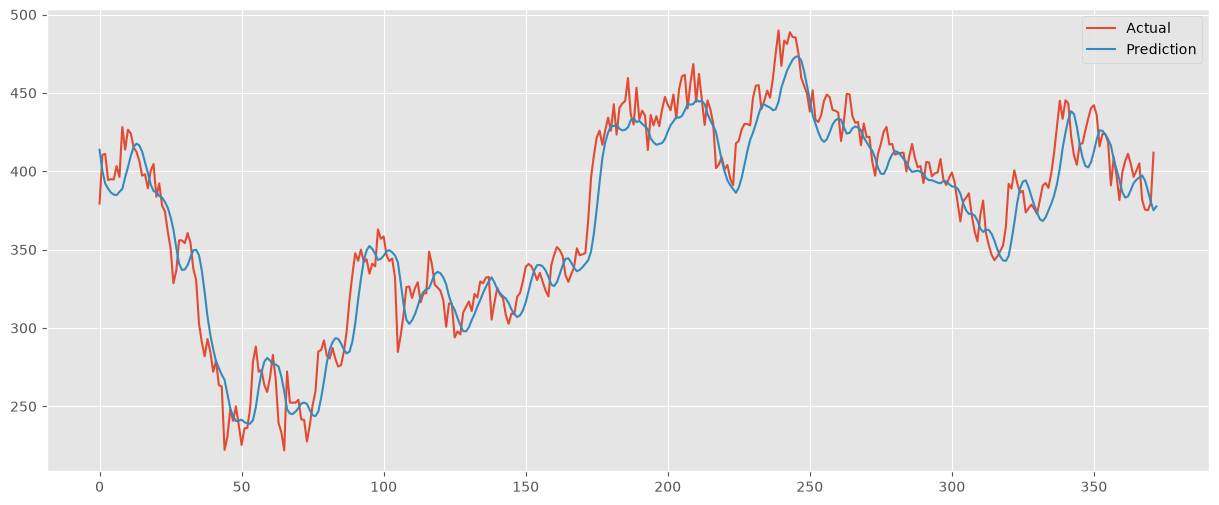

In [32]:
plt.figure(figsize=(15,6))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Prediction")

plt.legend()

plt.show()

22. Metrics

In [33]:
print("NaN in actual:", np.isnan(actual).sum())
print("NaN in pred:", np.isnan(pred).sum())

NaN in actual: 1
NaN in pred: 0


In [34]:
print(np.where(np.isnan(actual)))

(array([372]), array([0]))


In [35]:
print(close.isna().sum())
print(close[close.isna()])

1
Date
Date   NaN
Name: Close, dtype: float64


In [36]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Prediction": pred.flatten()
}).dropna()

lstm_mae = mean_absolute_error(
    results["Actual"],
    results["Prediction"]
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        results["Actual"],
        results["Prediction"]
    )
)

lstm_mape = mean_absolute_percentage_error(
    results["Actual"],
    results["Prediction"]
)

print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)

MAE : 13.994502611057735
RMSE: 17.773480492267336
MAPE: 0.03895865562773613


23. Model Comparison Table

In [37]:
comparison = pd.DataFrame({

    "Model":[

        "ARIMA",

        "LSTM"

    ],

    "MAE":[

        mae,

        lstm_mae

    ],

    "RMSE":[

        rmse,

        lstm_rmse

    ],

    "MAPE":[

        mape,

        lstm_mape

    ]

})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,54.441182,70.539346,0.172407
1,LSTM,13.994503,17.773480,0.038959


23. Best Model

In [38]:
comparison.sort_values(

    by="RMSE"

)

,Model,MAE,RMSE,MAPE
1,LSTM,13.994503,17.773480,0.038959
0,ARIMA,54.441182,70.539346,0.172407


In [41]:
forecast_steps = 252

future_forecast = arima_model.get_forecast(
    steps=forecast_steps
)

forecast_mean = future_forecast.predicted_mean

forecast_ci = future_forecast.conf_int(alpha=0.05)

c:\Users\Administrator\projects\portfolio-optimization-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
